# Recursion

In the first set of notes we saw many specific algorithms - now we will see specific ways of thinking. 

## Induction

The principle of induction states that, if $p(n)$ is a logical statement depending on some natural number $n$ (a *predicate* - does not have to depend on a natural number, but it should for induction in particular) then $(p(n_0)\cap(\forall k \in \N, k\geq n_0: p(k) \implies p(k+1)) \implies (\forall n \geq n_0: p(n)))$; i.e. if a property holds for some $n_0$ (the *base case*) and for all natural numbers $k\geq n_0$, if $p(k)$ holds, then $p(k+1)$ holds (the *inductive step*); then $p$ holds for all natural numbers $n\geq n_0$. 

For the analysis of certain algorithms, the following closed form is useful: $\sum_{i=0}^n 2^i=2^{n+1}-1$. To see this, let $S=1+2+...+2^n$. Then $2S=2+4+...+2^{n+1}$. Hence $2S-S=S=2^{n+1}-1$. 

For example, $\sum_{d=0}^{\log_2 n} 2^d=2^{\log_2 n+1}-1=2n-1$.

This can be proved using induction.

## Divide and Conquer

D&C is an algorithm design technique, which solves a large problem recursively in three steps:

1. **Divide** the problem in to a number of smaller subproblems, almost always of the same kind
2. **Conquer** the problems by solving them recursively
3. **Combine** the solutions into the solution to the original problem. 

For instance, in merge sort, you divide an array into smaller subarrays, which you then store (step 1); you sort these smaller subarrays (step 2); then you merge them into a larger sorted array (step 3). 

For the recursion to eventually go back up, there must be a subproblem small enough that it can be solved directly, without subdividing - this forms the **base case** of the algorithm. 

### Subproblem graphs

The *subproblem graph* of an instance of an algorithm is a directed graph in which each node represents a distinct subproblem (e.g. a part of the list), and there is a directed edge $u\rightarrow v$ if solving subproblem $u$ directly requires solving subproblem $v$. This graph must be acyclic (as otherwise some subproblem might depend on itself, preventing there being a valid order to compute the solution); equivalently, it must have a topological ordering. This can be guaranteed by making subproblems strictly "simpler" than their parents. Often, subproblem graphs will be trees. 

For merge sort, each node $(l,r)$ represents the subproblem of sorting the subarray $A[l...r]$; there are directed edges $(l,r)\rightarrow (l,m),(m+1,r)$ where $m=\lfloor \frac{l+r}{2} \rfloor$. For example:
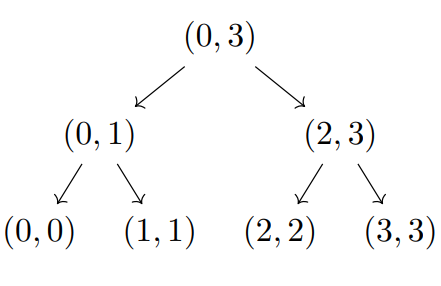

### Invocation trees

The *invocation tree* records the recursive calls made during the execution of an algorithm. Each node represents a call. The children of a parent are the calls invoked by it, and ordered by order of execution; when you 'traverse' the tree to get a list of the call order, you do a depth-first search (in particular, a *post-order traversal*). This must always be a tree, since each call can only have been invoked by one other (i.e. can only have one parent). In the example of merge sort, where $M-S$ is the main merge sort function and $M$ is the merge function:

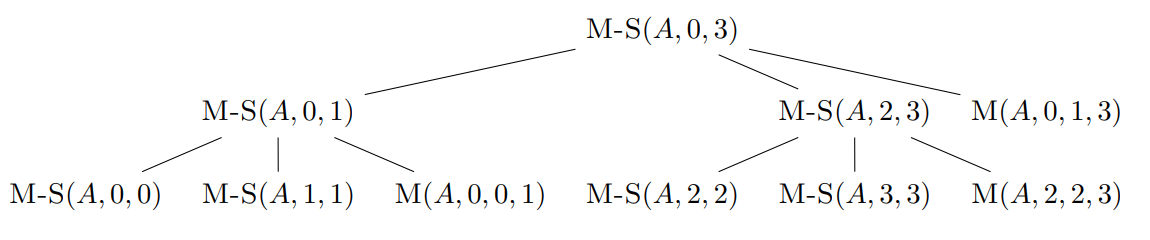

### Analysis

1. Write a *recurrence equation* with two cases:
    - Time to solve the smallest problem (base case) which should be $\Theta(1)$
    - Time to solve a bigger problem (recursive case) which is time to divide + time to conquer + time to combine
e.g. for merge sort, where $n$ is the size of the array to be sorted, the time to divide is $\Theta(1)$ - just indexing, the time to conquer is $2T(\frac{n}{2})$ - the time to apply the same function to a two subarrays of size $\frac{n}{2}$ (the inner part of this expression determines the depth of the tree, and the coefficient determines the number of branches at each node), and the time to merge is $\Theta(n)$. The time complexity will often be expressed recursively in this way.

$
T(n)=\begin{cases}
\Theta(1) & \text{if } n = 1\\
\Theta(1) + 2T(\frac{n}{2}) + \Theta(n) & \text{if } n > 1.
\end{cases}$

2. To simplify the recursive case, we combine the *divide* and *conquer* terms in one $\Theta$ term and replace asymptotic terms with their non-asymptotic counterparts; for example $cn^2$ instead of $\Theta(n^2)$ and $c$ instead of $\Theta(1)$. This means our recursive case now has only two terms, instead of 3.

$
T(n)=\begin{cases}
\Theta(1) & \text{if } n = 1\\
2T(\frac{n}{2}) + cn & \text{if } n > 1.
\end{cases}$

3. Now we draw the *recurrence tree* or *recursion tree* of the recursive case. In theory you should expand down to the base case, but in practise you only need to draw enough layers to recognise a pattern in the 'time complexity so far' for each layer. This allows you to find a closed-form (not recursive) expression for the recurrence equation. 

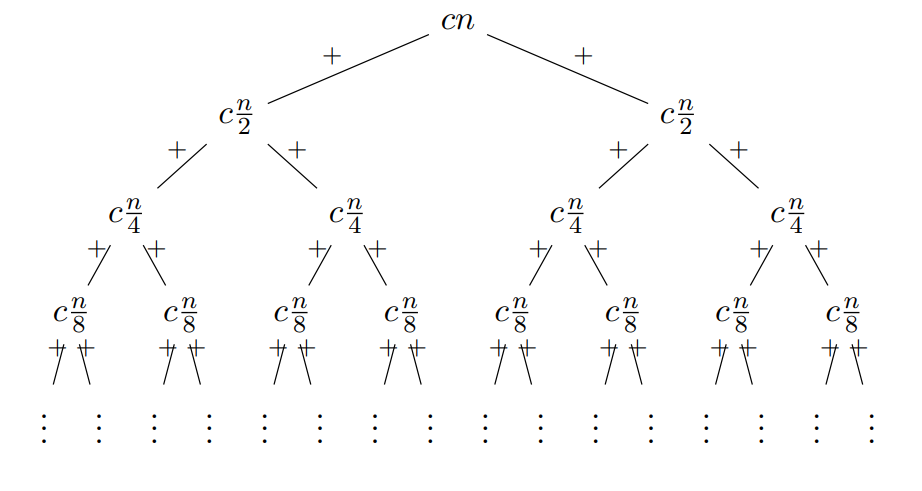

In this tree
- Each node is an expression for cost/runtime of a call; for non-leaf nodes, it is the sum of divide and combine times, and for leaf nodes, it is the constant base case time
- Each node subdivides into its subproblems
- Each subtree represents an entire subproblem (with the root being the initial subproblem itself and the children being subproblems); in particular, it is a recurrence tree for that subproblem
- The cost of a subproblem is the sum of all the nodes in that subtree

4. Now we find the closed-form expression for the sum of the nodes in the tree. For this, we need an expression for
- No. of nodes at each depth $d$
- Cost expression of each node at depth $d$
- From the produce of these, the sum of costs for all the nodes at $d$
- The depth of the recurrence tree, i.e. the maximum value of $d$, at which the base case is reached

To get the final cost, it often works to substitute your expression for the depth into $d$ in your sum of costs at a depth (the $\Theta$ term will usually only depend on the cost of the max. depth). More rigorously, the total cost is $\Sigma_{d=0}^{d_{max}} \text{cost at each depth}$.

For merge sort:
- No. of nodes at depth $d$ is $2^d$
- Cost expression of each node is $c\frac{n}{2^d}$
- Hence, the cost at each depth is $cn$
- When $\frac{n}{2^d}=1$, i.e. when $d=\log n$, the base case is reached
- Hence the sum of all costs $T(n)=cn(\log n + 1)$ which belongs to $\Theta(n \log n)$. (The +1 term comes from the $d=0$ level.)

### Example: Fibonacci

#### First: Fast exponentiation

If $n$ is even, $a^n=a^{\frac{n}{2}}a^{\frac{n}{2}}$; if $n$ is odd, $a^n=a^{\lfloor \frac{n}{2} \rfloor}a^{\lfloor \frac{n}{2} \rfloor}a$. This method of squaring allows us to reduce the power problem to a problem half its size at each step, giving a $\Theta(\log n)$ time complexity. The pseudocode is as follows:

```
def Power(a, n):
    if n = 0
        return 1
    else
        p ← Power(a, floor(n/2))
        if n is even
            return p × p
        else
            return a × p × p
```

#### Next: Proof of Matrix Fibonacci

$F_0=0, F_1=1, F_n=F_{n-1}+F_{n-2}$ for $n\geq 2$. Then taking the base case of $n=1$:
$\begin{bmatrix}
    F_{n+1}=1 & F_n=1 \\
    F_n=1 & F_{n-1}=0
\end{bmatrix} = 
\begin{bmatrix}
1 & 1 \\
1 & 0
\end{bmatrix}^1$

Next supposing that 

$\begin{bmatrix}
    F_{n+1} & F_n \\
    F_n & F_{n-1}
\end{bmatrix} = 
\begin{bmatrix}
1 & 1 \\
1 & 0
\end{bmatrix}^n$, we find that

$\begin{bmatrix}
    F_{n+2} & F_{n+1} \\
    F_{n+1} & F_n
\end{bmatrix} = 
\begin{bmatrix}
    F_{n+1}+F_n & F_n + F_{n-1} \\
    F_n + F_{n-1} & F_n + 0
\end{bmatrix} = 
\begin{bmatrix}
    F_{n+1} & F_n \\
    F_n & F_{n-1}
\end{bmatrix}
\begin{bmatrix}
1 & 1 \\
1 & 0
\end{bmatrix} =
\begin{bmatrix}
1 & 1 \\
1 & 0
\end{bmatrix}^{n+1}$

Hence proving by induction that
$\begin{bmatrix}
    F_{n+1} & F_n \\
    F_n & F_{n-1}
\end{bmatrix} = 
\begin{bmatrix}
1 & 1 \\
1 & 0
\end{bmatrix}^n$
for all $n$. 

#### Finally: Even Better Fibonacci

In [4]:
NUM_RMDS = 9   # number of right-most digits required

def multiply2by2(A, B):
    """Takes two 2-by-2 matrices, A and B, and returns their product. The
    product will only contain a limited number of digits to cope with
    large numbers.  The input and output matrices are in the form of
    lists of lists (of lengths 2). This function only works for 2-by-2
    matrices. The size (dimensions) of the input does not grow with
    respect to n in the original problem. Therefore the time
    complexity of this function is Theta(1). This is different from
    the general matrix multiplication problem where the time
    complexity for multiplying two n-by-n matrices is O(n^3).

    """

    # compute the matrix product
    product = [
        [A[0][0]*B[0][0]+A[0][1]*B[1][0],	A[0][0]*B[0][1]+A[0][1]*B[1][1]],	 
        [A[1][0]*B[0][0]+A[1][1]*B[1][0],	A[1][0]*B[0][1]+A[1][1]*B[1][1]]
        ]
    
    # retain only the required number of digits on the right
    product = [[x % 10**NUM_RMDS for x in row] for row in product]
    
    return product

def matrix_power(A, n):
    """Takes a 2x2 matrix A and a non-negative integer n as exponent and
    returns A raised to the power of n (which will be a 2x2 matrix)."""
    
    # if n is 0 then return the identity matrix.
    if n == 0:
        return [[1, 0],
                [0, 1]]
    
    # otherwise subdivide. 
    else:
        p = matrix_power(A, n // 2)
        if n % 2 == 0:
            return multiply2by2(p, p)
        else:
            return multiply2by2(A, multiply2by2(p, p))
    

def fib(n):
    """Returns the n-th Fibonacci number by raising a special matrix to the
    power of n and returning an element on the off-diagonal."""
    
    A = [[1, 1], 
         [1, 0]]
         
    return matrix_power(A, n)[0][1]

print(fib(100))


261915075


## Recursive programming

When you want to keep track of an object's value throughout your recursion, store it in an immutable object, like a list or a dictionary, and pass it into the recursive function as a parameter. 

When you are working with lists in recursion, avoid slicing the list (`l[n+1]`) and instead opt to use an index parameter, greatly reducing time complexity.